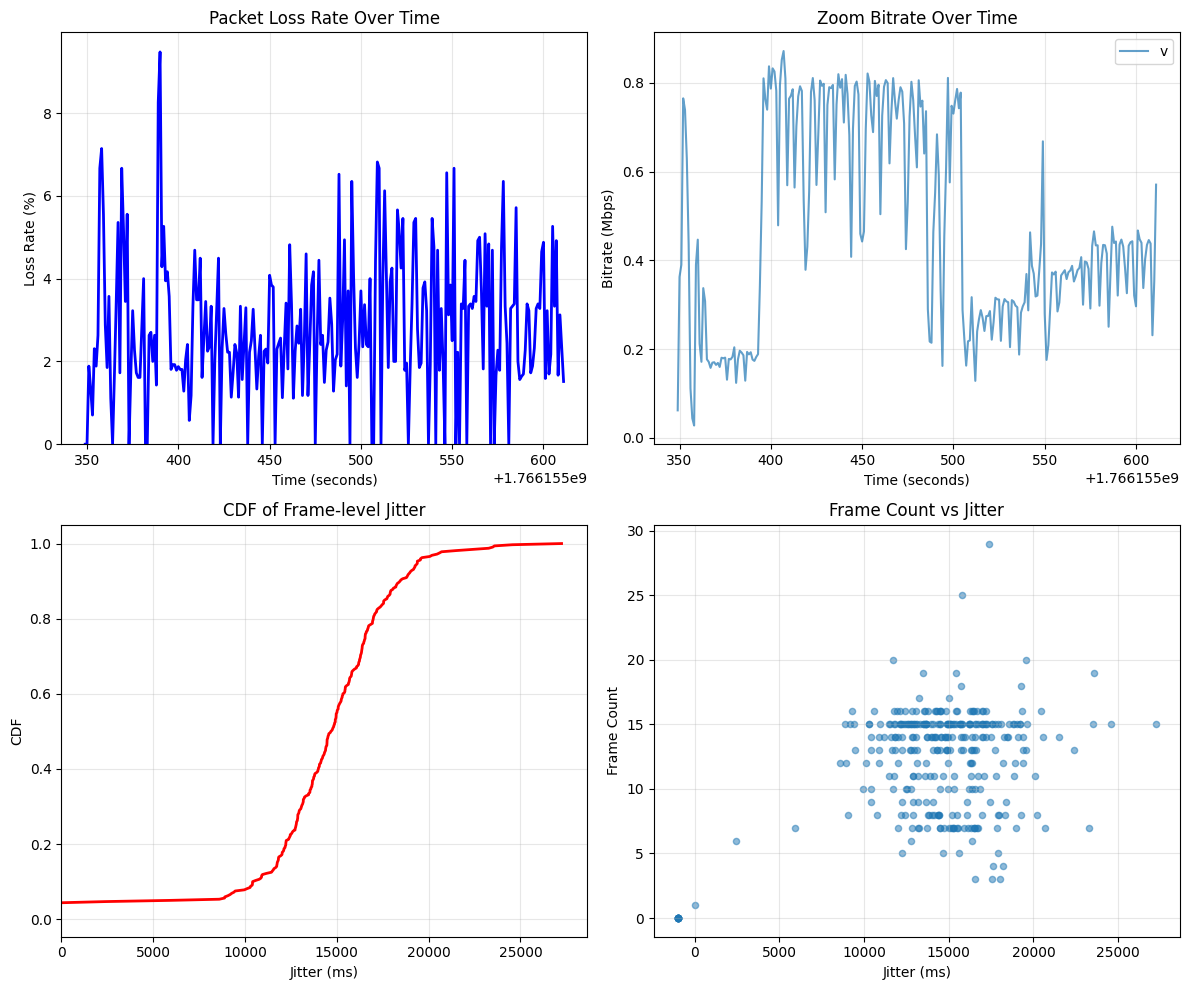

ZOOM PERFORMANCE SUMMARY

1. OVERALL STATISTICS:
   • Total packets: 15,583
   • Lost packets: 487
   • Average loss rate: 2.78%

2. JITTER STATISTICS:
   • Mean jitter: 14247.04 ms
   • 95th percentile: 19387.25 ms
   • Max jitter: 27242.50 ms

3. BITRATE STATISTICS:
   • Average bitrate: 0.38 Mbps
   • Peak bitrate: 0.82 Mbps

4. BY MEDIA TYPE:
   • v:
     - Loss rate: 2.78%
     - Avg jitter: 14247.04 ms
     - Avg bitrate: 0.38 Mbps

✓ Results saved:
  - loss_rate_over_time.csv
  - zoom_analysis_results.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("stats.csv")

# Clean data
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 1. LOSS RATE ANALYSIS
# Compute loss rate per packet
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Loss rate over time (1-second bins)
loss_over_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()
loss_over_time.to_csv("loss_rate_over_time.csv", index=False)

# 2. BITRATE ANALYSIS (Section 5.1)
if 'bytes' in df.columns:
    df['bitrate_mbps'] = (df['bytes'] * 8) / 1e6  # Convert to Mbps
    
    # Bitrate over time
    if 'media_type' in df.columns:
        bitrate_by_type = df.groupby(['ts_s', 'media_type'])['bitrate_mbps'].sum().unstack().fillna(0)
    else:
        bitrate_by_type = df.groupby('ts_s')['bitrate_mbps'].sum()

# 3. JITTER ANALYSIS (Section 5.4)
if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000  # Convert to ms

# 4. PLOTS
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Loss rate over time
axes[0,0].plot(loss_over_time['ts_s'], loss_over_time['loss_rate'] * 100, 'b-', linewidth=2)
axes[0,0].set_xlabel('Time (seconds)')
axes[0,0].set_ylabel('Loss Rate (%)')
axes[0,0].set_title('Packet Loss Rate Over Time')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim(0)

# Plot 2: Bitrate over time
if 'bitrate_mbps' in df.columns:
    if 'media_type' in df.columns and isinstance(bitrate_by_type, pd.DataFrame):
        for media_type in bitrate_by_type.columns:
            axes[0,1].plot(bitrate_by_type.index, bitrate_by_type[media_type], 
                          label=media_type, alpha=0.7)
        axes[0,1].legend()
    else:
        axes[0,1].plot(bitrate_by_type.index, bitrate_by_type.values, 'g-', alpha=0.7)
    axes[0,1].set_xlabel('Time (seconds)')
    axes[0,1].set_ylabel('Bitrate (Mbps)')
    axes[0,1].set_title('Zoom Bitrate Over Time')
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Jitter CDF
if 'jitter_ms' in df.columns:
    jitter_data = df['jitter_ms'].dropna()
    sorted_jitter = np.sort(jitter_data)
    cdf = np.arange(1, len(sorted_jitter) + 1) / len(sorted_jitter)
    axes[1,0].plot(sorted_jitter, cdf, 'r-', linewidth=2)
    axes[1,0].set_xlabel('Jitter (ms)')
    axes[1,0].set_ylabel('CDF')
    axes[1,0].set_title('CDF of Frame-level Jitter')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].set_xlim(0)

# Plot 4: Scatter: Jitter vs Frames
if 'frames' in df.columns and 'jitter_ms' in df.columns:
    sample_size = min(500, len(df))
    plot_df = df.sample(sample_size) if len(df) > sample_size else df
    axes[1,1].scatter(plot_df['jitter_ms'], plot_df['frames'], alpha=0.5, s=20)
    axes[1,1].set_xlabel('Jitter (ms)')
    axes[1,1].set_ylabel('Frame Count')
    axes[1,1].set_title('Frame Count vs Jitter')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zoom_analysis_results.png', dpi=150)
plt.show()

# 5. SUMMARY STATISTICS
print("=" * 50)
print("ZOOM PERFORMANCE SUMMARY")
print("=" * 50)

# Overall statistics
print(f"\n1. OVERALL STATISTICS:")
print(f"   • Total packets: {df['pkts'].sum():,.0f}")
print(f"   • Lost packets: {df['lost'].sum():,.0f}")
print(f"   • Average loss rate: {df['loss_rate'].mean()*100:.2f}%")

# Jitter stats
if 'jitter_ms' in df.columns:
    print(f"\n2. JITTER STATISTICS:")
    print(f"   • Mean jitter: {df['jitter_ms'].mean():.2f} ms")
    print(f"   • 95th percentile: {np.percentile(df['jitter_ms'].dropna(), 95):.2f} ms")
    print(f"   • Max jitter: {df['jitter_ms'].max():.2f} ms")

# Bitrate stats
if 'bitrate_mbps' in df.columns:
    print(f"\n3. BITRATE STATISTICS:")
    print(f"   • Average bitrate: {df['bitrate_mbps'].mean():.2f} Mbps")
    print(f"   • Peak bitrate: {df['bitrate_mbps'].max():.2f} Mbps")

# By media type if available
if 'media_type' in df.columns:
    print(f"\n4. BY MEDIA TYPE:")
    for media_type in df['media_type'].unique():
        media_df = df[df['media_type'] == media_type]
        print(f"   • {media_type}:")
        print(f"     - Loss rate: {media_df['loss_rate'].mean()*100:.2f}%")
        if 'jitter_ms' in df.columns:
            print(f"     - Avg jitter: {media_df['jitter_ms'].mean():.2f} ms")
        if 'bitrate_mbps' in df.columns:
            print(f"     - Avg bitrate: {media_df['bitrate_mbps'].mean():.2f} Mbps")

print(f"\n✓ Results saved:")
print(f"  - loss_rate_over_time.csv")
print(f"  - zoom_analysis_results.png")
print("=" * 50)



# audio screenshare with two users 

File loaded successfully!
Columns: ['ts_s', 'report_count', 'rtp_ssrc', 'media_type', 'stream_type', 'ip_src', 'tp_src', 'ip_dst', 'tp_dst', 'pkts', 'bytes', 'lost', 'duplicate', 'out_of_order', 'frames', 'mean_frame_len', 'mean_jitter']

First few rows:
         ts_s  report_count  rtp_ssrc media_type stream_type         ip_src  \
0  1766155349             0  16778241          v           m  192.168.88.72   
1  1766155349             0  16778241          v           f  192.168.88.72   
2  1766155350             1  16778241          v           m  192.168.88.72   
3  1766155350             1  16778241          v           f  192.168.88.72   
4  1766155351             2  16778241          v           m  192.168.88.72   

   tp_src           ip_dst  tp_dst  pkts  bytes  lost  duplicate  \
0   49718  144.195.129.149    8801    11   6616     0          0   
1   49718  144.195.129.149    8801     2   1158     0          0   
2   49718  144.195.129.149    8801    51  40329     0          0  

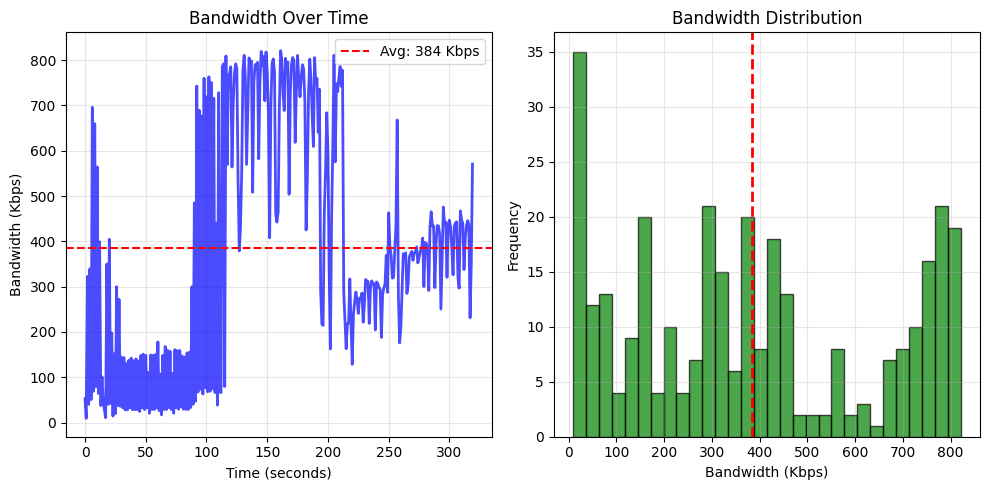


=== FOR YOUR PAPER ===
'Video stream bandwidth averages 0.4 Mbps (384 Kbps), ranging from 0.0 to 0.8 Mbps.'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the stats.csv file
df = pd.read_csv('stats.csv')

print("File loaded successfully!")
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# 2. Check which column contains bandwidth data
# Try different possible column names
bitrate_col = None
for col in ['bytes_per_sec', 'bitrate_bps', 'bytes', 'bitrate', 'bytes_sec']:
    if col in df.columns:
        bitrate_col = col
        print(f"\nUsing column: '{bitrate_col}'")
        break

if bitrate_col:
    # 3. Convert to Kbps based on column name
    if 'bytes' in bitrate_col:  # bytes_per_sec or bytes_sec
        kbps = df[bitrate_col] * 8 / 1000  # bytes/sec → Kbps
        unit = "bytes/sec → Kbps"
    elif 'bps' in bitrate_col:  # bitrate_bps
        kbps = df[bitrate_col] / 1000  # bps → Kbps
        unit = "bps → Kbps"
    else:  # Unknown, assume Kbps
        kbps = df[bitrate_col]
        unit = "assuming Kbps"
    
    print(f"Conversion: {unit}")
    
    # 4. Calculate statistics for your paper
    print(f"\n=== BANDWIDTH STATISTICS ===")
    print(f"Average: {kbps.mean():.0f} Kbps ({kbps.mean()/1000:.2f} Mbps)")
    print(f"Minimum: {kbps.min():.0f} Kbps")
    print(f"Maximum: {kbps.max():.0f} Kbps")
    print(f"Std Dev: {kbps.std():.0f} Kbps")
    print(f"Median:  {kbps.median():.0f} Kbps")
    print(f"95th %:  {kbps.quantile(0.95):.0f} Kbps")
    
    # 5. Create simple plot
    plt.figure(figsize=(10, 5))
    
    # Time series plot
    plt.subplot(1, 2, 1)
    plt.plot(kbps.values, color='blue', alpha=0.7, linewidth=2)
    plt.axhline(y=kbps.mean(), color='red', linestyle='--', label=f'Avg: {kbps.mean():.0f} Kbps')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Bandwidth (Kbps)')
    plt.title('Bandwidth Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Histogram
    plt.subplot(1, 2, 2)
    plt.hist(kbps.values, bins=30, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(x=kbps.mean(), color='red', linestyle='--', linewidth=2)
    plt.xlabel('Bandwidth (Kbps)')
    plt.ylabel('Frequency')
    plt.title('Bandwidth Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('bandwidth_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 6. For your paper:
    print(f"\n=== FOR YOUR PAPER ===")
    print(f"'Video stream bandwidth averages {kbps.mean()/1000:.1f} Mbps "
          f"({kbps.mean():.0f} Kbps), ranging from {kbps.min()/1000:.1f} to "
          f"{kbps.max()/1000:.1f} Mbps.'")
    
else:
    print("\nERROR: No bandwidth column found!")
    print("Your stats.csv has these columns:", df.columns.tolist())
    print("\nTry looking for one of these columns in your data.")